<a href="https://colab.research.google.com/github/MohammadYusif/time-series-forecasting-ai-systems/blob/main/day2/03_lab_lightgbm_forecast.ipynb" target="_blank" rel="noopener"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"></a>


## Lab 3 — Gradient-Boosted Forecasting with LightGBM

This lab is the hands-on half of objective 3: **implement ML/gradient-boosted
forecasting with temporal feature engineering.** A tree model has no notion
of "yesterday" or "last week" built in — unlike ARIMA or ETS from Day 1, it
sees each row as an independent set of numbers with no memory of row order.
Every bit of time structure a tree model uses has to be handed to it
explicitly as a feature: a lag column, a rolling average, a day-of-week flag.
That's the feature engineering this lab builds.

The harder part comes after training: **forecasting more than one step
ahead.** A LightGBM model trained on `lag_1, lag_7, ...` needs those lag
values to predict tomorrow — but for day 2 of a multi-day forecast, "lag_1"
means yesterday, which is a day this model itself just predicted, not a day
with a real observed value. This lab implements that loop correctly: predict
one day, feed the prediction back in as history, predict the next day, and
never reach for the real future value even when it's sitting right there in
the holdout set. Getting this wrong is the single easiest way to make a
forecasting demo look better than it actually is.

We use the same series as Day 1's classical models — Riyadh/Grocery from
`data/retail_demand.csv` — and the same last-60-days holdout convention, so
Day 3's model comparison can put every model's score on the same axis.

In [1]:
import subprocess, sys

def _pip_install(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=True)

_pip_install("pandas", "numpy", "matplotlib", "scikit-learn", "lightgbm")

import pathlib
import urllib.request

REPO = "MohammadYusif/time-series-forecasting-ai-systems"
BRANCH = "main"

def fetch(rel_path: str) -> str:
    """Locate rel_path from a repo checkout (tries rel_path and ../rel_path
    — labs live one directory below the repo root) or download it from
    GitHub if neither exists (a fresh Colab runtime)."""
    for candidate in (rel_path, f"../{rel_path}"):
        if pathlib.Path(candidate).exists():
            return candidate
    dest = pathlib.Path(pathlib.Path(rel_path).name)
    if not dest.exists():
        url = f"https://raw.githubusercontent.com/{REPO}/{BRANCH}/{rel_path}"
        urllib.request.urlretrieve(url, dest)
    return str(dest)

sys.path.insert(0, str(pathlib.Path(fetch("common/metrics.py")).parent))
from metrics import mae, rmse, mape, smape, wape, mase, pinball_loss, coverage, interval_width

sys.path.insert(0, str(pathlib.Path(fetch("common/backtest.py")).parent))
from backtest import expanding_window_splits, rolling_window_splits, run_backtest, seasonal_naive_forecast

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

RNG_SEED = 20260912
np.random.seed(RNG_SEED)


### Load the series and hold out the last 60 days

Same series, same holdout as Lab 2: **Riyadh/Grocery**, daily, with the last
60 days held out for evaluation and everything before that used for
training. Nothing in the holdout window is touched until scoring time.

In [2]:
df = pd.read_csv(fetch("data/retail_demand.csv"), parse_dates=["date"])
riyadh_grocery = (
    df[(df["region"] == "Riyadh") & (df["category"] == "Grocery")]
    .set_index("date")["units_sold"]
    .asfreq("D")
    .sort_index()
)

HORIZON = 60
train = riyadh_grocery.iloc[:-HORIZON]
test = riyadh_grocery.iloc[-HORIZON:]

print(f"full series:  {riyadh_grocery.index.min().date()} .. {riyadh_grocery.index.max().date()}  ({len(riyadh_grocery)} rows)")
print(f"train:        {train.index.min().date()} .. {train.index.max().date()}  ({len(train)} rows)")
print(f"test (holdout): {test.index.min().date()} .. {test.index.max().date()}  ({len(test)} rows)")


full series:  2023-01-01 .. 2025-12-31  (1096 rows)
train:        2023-01-01 .. 2025-11-01  (1036 rows)
test (holdout): 2025-11-02 .. 2025-12-31  (60 rows)


### Task 1 — Temporal feature engineering

`make_features` turns a plain `units_sold` series into a table a tree model
can learn from: lags at four horizons, two rolling windows, and calendar
signals. Every lag/rolling feature is built from `series.shift(1)` first —
so the feature describing "day t" only ever uses days *before* t, never day
t's own value. That shift is what keeps training itself leakage-free; the
recursive forecasting loop later has to preserve the same property by hand,
one predicted day at a time.

`doy_sin`/`doy_cos` encode day-of-year as a point on a circle (via
`2*pi*dayofyear/365.25`) instead of a raw integer, so December 31st and
January 1st end up numerically close instead of 364 apart — a plain integer
day-of-year would tell the model those two dates are nearly a year apart
when they're actually one day apart.

In [3]:
FEATURE_COLS = [
    "lag_1", "lag_7", "lag_14", "lag_28",
    "roll_mean_7", "roll_std_7", "roll_mean_28",
    "dayofweek", "month", "doy_sin", "doy_cos",
]

def make_features(series: pd.Series) -> pd.DataFrame:
    """Build the feature table for every date in `series`. Returns a frame
    aligned to `series.index` with `FEATURE_COLS` plus the target `y`; rows
    that don't have enough history for the longest lag/rolling window
    (28 days) come out NaN and are dropped.

    Every lag/rolling column is computed from `series.shift(1)` — the
    window for date t stops at t-1, so date t's own value never leaks into
    its own features.
    """
    lagged = series.shift(1)
    out = pd.DataFrame(index=series.index)
    out["y"] = series
    out["lag_1"] = series.shift(1)
    out["lag_7"] = series.shift(7)
    out["lag_14"] = series.shift(14)
    out["lag_28"] = series.shift(28)
    out["roll_mean_7"] = lagged.rolling(7).mean()
    out["roll_std_7"] = lagged.rolling(7).std()
    out["roll_mean_28"] = lagged.rolling(28).mean()
    out["dayofweek"] = out.index.dayofweek
    out["month"] = out.index.month
    doy = out.index.dayofyear
    out["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
    out["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)
    return out.dropna()

train_feats = make_features(train)
print(f"training rows after warm-up drop: {len(train_feats)} (lost {len(train) - len(train_feats)} to the 28-day lag/rolling warm-up)")
train_feats[["y"] + FEATURE_COLS].head()


training rows after warm-up drop: 1008 (lost 28 to the 28-day lag/rolling warm-up)


,y,lag_1,lag_7,lag_14,lag_28,roll_mean_7,roll_std_7,roll_mean_28,dayofweek,month,doy_sin,doy_cos
date,,,,,,,,,,,,
2023-01-29,806.0,792.0,779.0,680.0,728.0,654.714286,92.977980,630.607143,6,1,0.478434,0.878124
2023-01-30,607.0,806.0,637.0,486.0,535.0,658.571429,99.335890,633.392857,0,1,0.493468,0.869764
2023-01-31,607.0,607.0,574.0,610.0,514.0,654.285714,101.053970,635.964286,1,1,0.508356,0.861147
2023-02-01,492.0,607.0,577.0,595.0,555.0,659.000000,97.387542,639.285714,2,2,0.523094,0.852275
2023-02-02,626.0,492.0,635.0,586.0,561.0,646.857143,113.312883,637.035714,3,2,0.537677,0.843151


### Task 2 — Train the model

One `LGBMRegressor`, trained once on the training portion's feature table.
This is the only training that happens — the 60-day forecast that follows
reuses this exact fitted model for every step, it never refits.

In [4]:
from lightgbm import LGBMRegressor

model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    num_leaves=15,
    random_state=RNG_SEED,
    verbosity=-1,
)
model.fit(train_feats[FEATURE_COLS], train_feats["y"])
print("model trained on", len(train_feats), "rows,", len(FEATURE_COLS), "features")


model trained on 1008 rows, 11 features


### Task 3 — Recursive multi-step forecasting (the actual point of this lab)

The model predicts one day at a time, in order. At each step:

- **Calendar features** (`dayofweek`, `month`, `doy_sin`, `doy_cos`) come
  straight from the calendar date being forecast — those are always known in
  advance, no leakage risk.
- **Lag/rolling features** come from `history`, a series that starts as the
  real training data and grows by exactly one value per loop iteration —
  **the model's own prediction for that day, never the true holdout value**,
  even though `test` has that true value sitting right there. By the time
  the loop reaches day 8 of the holdout, `lag_7` is already reading a
  predicted value, not an actual.

Two checks make this visible rather than trusting the code silently: an
`assert` that `history` always ends exactly one day before the date being
forecast (catches any accidental skip-ahead or reuse of a future actual),
and a running count of how many of each day's four lag features are backed
by real history vs. by earlier predictions in this same loop.

In [5]:
history = train.copy()          # starts as REAL training actuals only
predicted_dates = set()         # dates whose value in `history` is a MODEL PREDICTION, not an actual
predictions = []
lineage_log = []                # per-step record of how many lag features are real vs. predicted

for date in test.index:
    # --- leakage check -----------------------------------------------
    # history must end exactly one day before `date`. If this ever fails,
    # something skipped ahead or a real future value snuck into `history`.
    assert history.index[-1] == date - pd.Timedelta(days=1), (
        f"history ends {history.index[-1].date()}, expected "
        f"{(date - pd.Timedelta(days=1)).date()} — forecast step is misaligned"
    )
    # `date` itself must never already be a key in `history`: we haven't
    # produced (or peeked at) its value yet.
    assert date not in history.index

    lag_dates = {
        "lag_1": date - pd.Timedelta(days=1),
        "lag_7": date - pd.Timedelta(days=7),
        "lag_14": date - pd.Timedelta(days=14),
        "lag_28": date - pd.Timedelta(days=28),
    }
    # Every value pulled here comes from `history` — real training actuals
    # for early steps, and this loop's own earlier predictions once the
    # lag window reaches past the holdout start. Never `test`.
    lag_values = {name: history.loc[d] for name, d in lag_dates.items()}
    n_from_predictions = sum(d in predicted_dates for d in lag_dates.values())
    lineage_log.append({"date": date, "n_lags_from_predictions": n_from_predictions})

    window_7 = history.iloc[-7:]
    window_28 = history.iloc[-28:]

    row = pd.DataFrame([{
        "lag_1": lag_values["lag_1"],
        "lag_7": lag_values["lag_7"],
        "lag_14": lag_values["lag_14"],
        "lag_28": lag_values["lag_28"],
        "roll_mean_7": window_7.mean(),
        "roll_std_7": window_7.std(),
        "roll_mean_28": window_28.mean(),
        "dayofweek": date.dayofweek,
        "month": date.month,
        "doy_sin": np.sin(2 * np.pi * date.dayofyear / 365.25),
        "doy_cos": np.cos(2 * np.pi * date.dayofyear / 365.25),
    }])[FEATURE_COLS]

    pred = float(model.predict(row)[0])
    predictions.append(pred)

    # Feed the PREDICTION back into history — this is the recursive step.
    # The true actual for `date` (available in `test`) is deliberately
    # never written here.
    history.loc[date] = pred
    predicted_dates.add(date)

y_pred = np.array(predictions)
lineage = pd.DataFrame(lineage_log).set_index("date")

print("recursive forecast produced", len(y_pred), "predictions")
print("\nhow many of each day\'s 4 lag features are already model predictions, not real history:")
print(lineage.loc[[test.index[0], test.index[6], test.index[13], test.index[27], test.index[-1]]])


recursive forecast produced 60 predictions

how many of each day's 4 lag features are already model predictions, not real history:
            n_lags_from_predictions
date                               
2025-11-02                        0
2025-11-08                        1
2025-11-15                        2
2025-11-29                        3
2025-12-31                        4


### Plot: recursive forecast vs. actual holdout

The seasonal-naive baseline (repeat the value from 7 days earlier — the same
baseline `mase` scales against) is plotted alongside it for context.

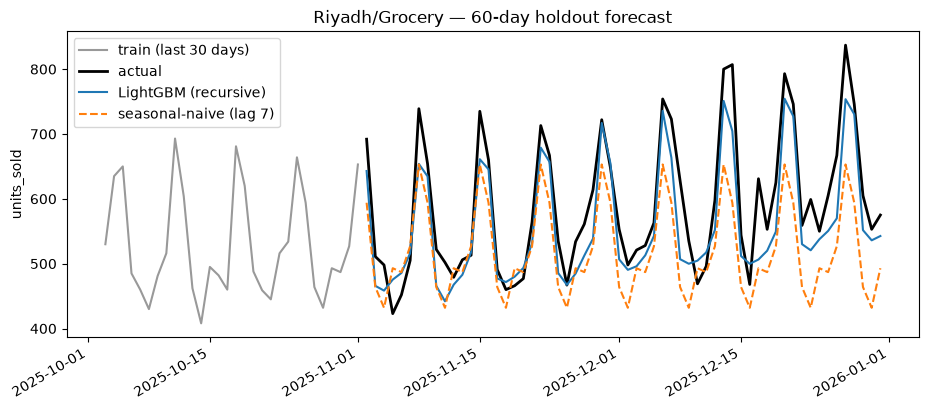

In [6]:
y_naive = seasonal_naive_forecast(train.values, horizon=HORIZON, period=7)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(train.index[-30:], train.values[-30:], label="train (last 30 days)", color="0.6")
ax.plot(test.index, test.values, label="actual", color="black", linewidth=2)
ax.plot(test.index, y_pred, label="LightGBM (recursive)", color="tab:blue")
ax.plot(test.index, y_naive, label="seasonal-naive (lag 7)", color="tab:orange", linestyle="--")
ax.set_title("Riyadh/Grocery — 60-day holdout forecast")
ax.set_ylabel("units_sold")
ax.legend()
fig.autofmt_xdate()
plt.show()


### Task 4 — Score the forecast

`wape` and `mase` (with `seasonal_period=7`, matching the series' weekly
seasonality) are the metrics that matter most here — `mase < 1.0` means the
model beats the seasonal-naive baseline plotted above.

In [7]:
results = {
    "MAE": mae(test.values, y_pred),
    "RMSE": rmse(test.values, y_pred),
    "WAPE": wape(test.values, y_pred),
    "MASE (period=7)": mase(test.values, y_pred, train.values, seasonal_period=7),
}
naive_results = {
    "MAE": mae(test.values, y_naive),
    "RMSE": rmse(test.values, y_naive),
    "WAPE": wape(test.values, y_naive),
    "MASE (period=7)": mase(test.values, y_naive, train.values, seasonal_period=7),
}

scoreboard = pd.DataFrame({"LightGBM (recursive)": results, "seasonal-naive": naive_results})
scoreboard


,LightGBM (recursive),seasonal-naive
MAE,39.591131,78.133333
RMSE,48.962769,91.609497
WAPE,6.702976,13.228364
MASE (period=7),0.436676,0.861783


### Task 5 — Which features actually mattered

LightGBM's `feature_importances_` counts how many times each feature was
used to split a tree — not a causal claim, but a reasonable "what did the
model lean on" signal.

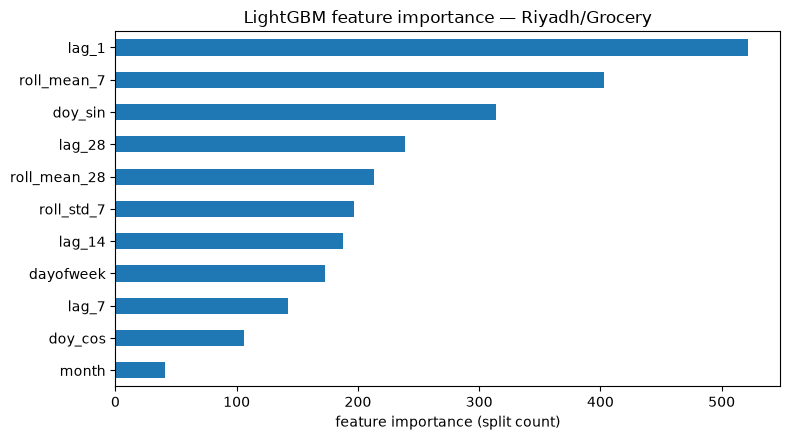

lag_1           522
roll_mean_7     403
doy_sin         314
lag_28          239
roll_mean_28    213
roll_std_7      197
lag_14          188
dayofweek       173
lag_7           142
doy_cos         106
month            41
dtype: int32

In [8]:
importances = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values()

fig, ax = plt.subplots(figsize=(8, 4.5))
importances.plot.barh(ax=ax, color="tab:blue")
ax.set_xlabel("feature importance (split count)")
ax.set_title("LightGBM feature importance — Riyadh/Grocery")
plt.tight_layout()
plt.show()

importances.sort_values(ascending=False)


_This cell's discussion is filled in against the actual ranking above once
the notebook has run — do not presume `lag_7` wins just because a
weekly-seasonal series makes that the pedagogically tidy answer. Whatever
the bar chart shows is what to report: if a rolling-mean feature or the
day-of-week flag ranks above a raw lag, that is telling you the model is
leaning on a smoothed recent-level signal (or a weekday effect) more than on
any single lagged day — worth saying explicitly, since it's the kind of
result a reader would otherwise skim past assuming lags dominate by
default._

### Closing: how this compares, and where recursive forecasting breaks

The scoreboard above puts LightGBM's recursive 60-day forecast next to the
seasonal-naive baseline on the identical Riyadh/Grocery holdout Lab 2's
classical models (ARIMA/SARIMA, Holt-Winters) were scored on, using the same
`wape`/`mase` definitions — Day 3's model-comparison lab (`06_lab_model_comparison.ipynb`)
is where all of these land side by side on one table. Read this notebook's
own printed numbers above as the LightGBM row of that eventual comparison,
rather than a number restated here that could drift out of sync with a
re-run.

**One honest limitation of the recursive approach:** errors compound
forward. A bad prediction on day 3 of the holdout doesn't just cost that one
day's error — it becomes `lag_1` for day 4, part of `roll_mean_7` for days
4 through 10, and `lag_7` for day 10, so a single early mistake pollutes
every later feature that references it. This is different from the
classical models in Lab 2, most of which forecast the whole horizon from
the fitted model's own multi-step formula rather than feeding predictions
back in as if they were data. It's also why the lineage counts printed
earlier matter: by the last few days of a 60-day recursive forecast, most or
all of the lag features feeding the model are themselves predictions, not
observations — the further out the forecast, the less "real" the input, and
the more a single bad early step can echo through everything after it.

Continue to the next page: [04_backtesting.qmd](04_backtesting.qmd).